# Projet - Prédiction du décès chez des patients atteints d’insuffisance cardiaque
# Partie 1
## 1) Introduction
### Objectif du projet :

L’objectif de ce notebook est de construire et comparer plusieurs modèles de classification supervisée afin de prédire la variable cible :

death_event :
	•	0 -> patient survivant
	•	1 -> patient décédé durant la période de suivi

Nous utilisons le dataset Heart Failure Clinical Records, contenant 299 patients et 12 variables cliniques.

⸻

### Description du dataset

Le dataset contient des variables cliniques mesurées chez des patients atteints d’insuffisance cardiaque :
	•	Variables démographiques : age, sex
	•	Variables biologiques :
serum_creatinine, serum_sodium, platelets, creatinine_phosphokinase
	•	Variables médicales binaires :
anaemia, diabetes, high_blood_pressure, smoking
	•	Variable cardiaque clé :
ejection_fraction
	•	Variable de suivi :
time
	•	Variable cible :
death_event

Il n’y a pas de valeurs manquantes dans le dataset.

⸻

In [9]:
pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [11]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_failure_clinical_records = fetch_ucirepo(id=519)

In [12]:
df = heart_failure_clinical_records.data.original

## 2) Exploration initiale des données

Après avoir chargé le dataset Heart Failure Clinical Records, nous effectuons une première exploration des données.

Nous vérifions :
	•	la présence éventuelle de valeurs manquantes,
	•	la structure du dataset,
	•	et un aperçu des premières observations.

Cette étape est essentielle afin de s’assurer que les données sont exploitables pour l’apprentissage automatique.

In [13]:
# Print the number of missing values in each column to verify that missing values were injected
missing_values = df.isnull().sum()
print(missing_values)      

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
death_event                 0
dtype: int64


Ce dataset ne contient aucune valeur manquante.

In [14]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Nous examinons la structure du dataset afin de vérifier le nombre d’observations, le nombre de variables ainsi que leurs types (numériques, binaires, continues).

Le dataset contient 299 observations et 13 variables, dont la variable cible death_event.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  death_event               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [16]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## 3) Analyse exploratoire des relations entre variables

Text(0.5, 0.98, 'Pairwise Relationships Between Features')

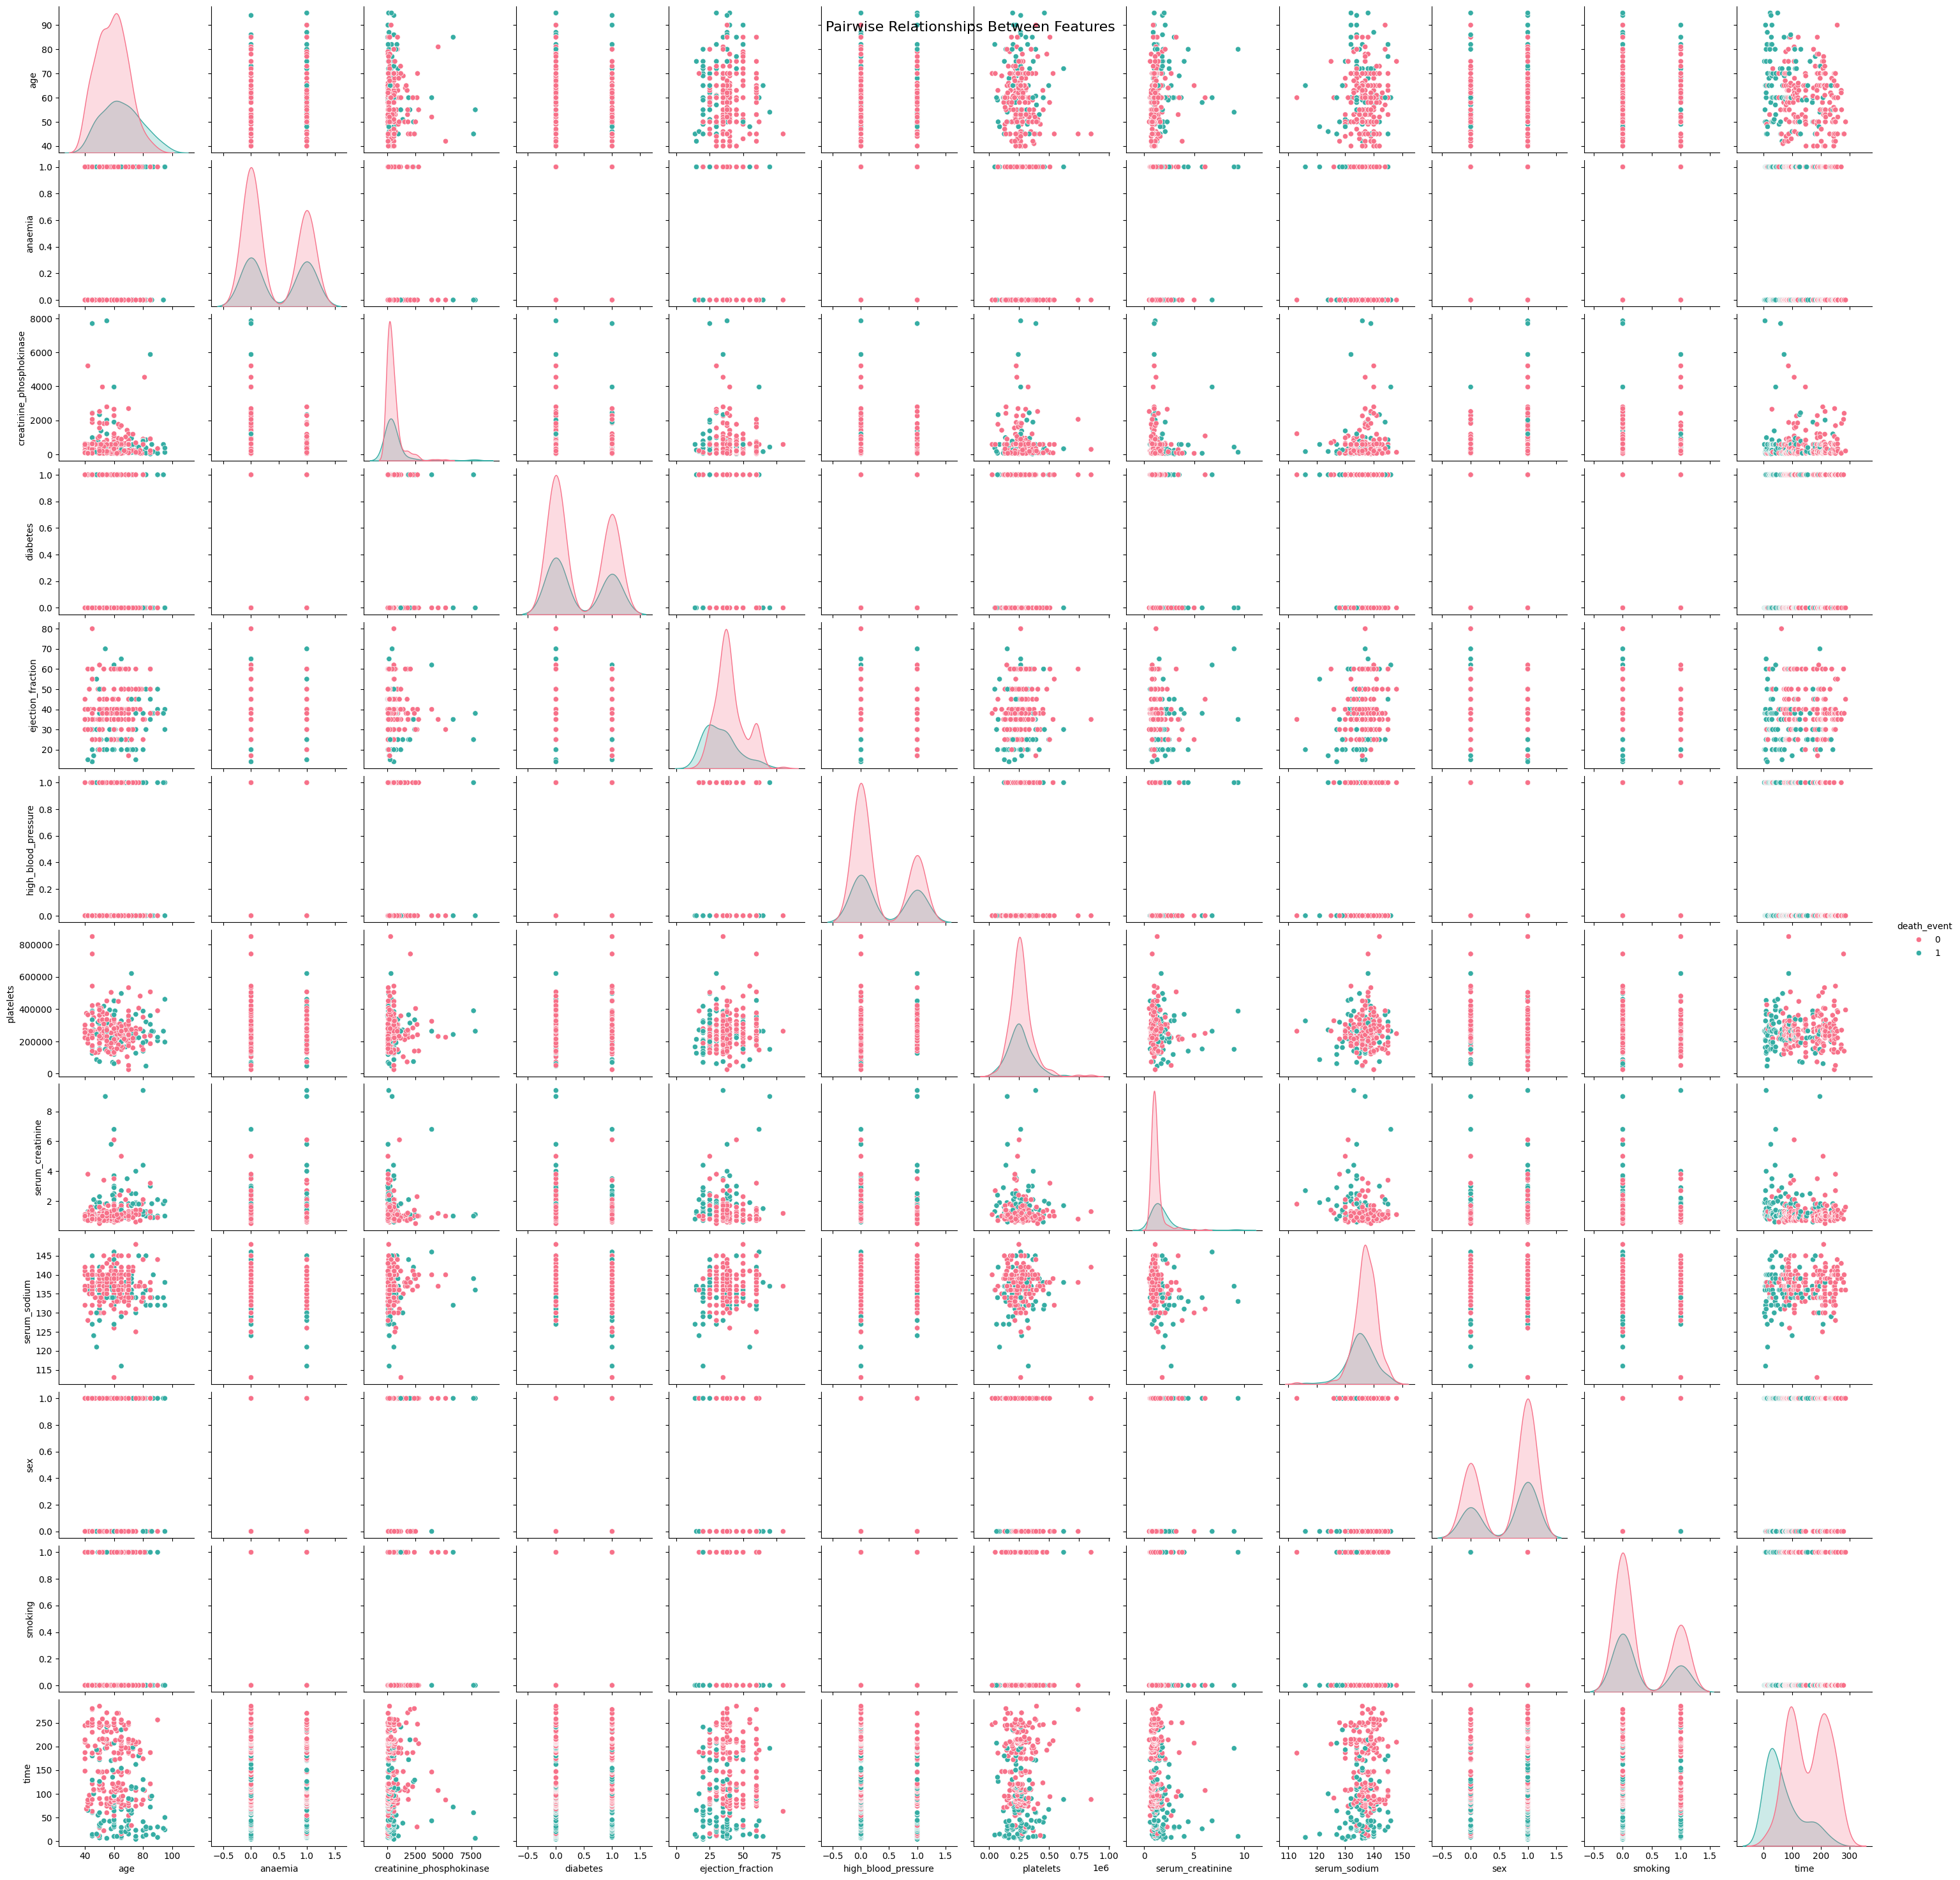

In [17]:
# Plot pairwise relationships between features using seaborn's pairplot
sns.pairplot(df, hue="death_event", palette="husl")
plt.suptitle("Pairwise Relationships Between Features", fontsize=16)


Nous avons représenté les relations bivariées entre les variables du dataset à l’aide d’un pairplot, en colorant les observations selon la variable cible death_event (rouge = survivants, bleu = décédés).

On observe que :
	•	Les variables binaires (anaemia, diabetes, high_blood_pressure, sex, smoking) apparaissent sous forme de bandes verticales ou horizontales, ce qui est cohérent avec leur nature catégorielle.
	•	Certaines variables continues présentent une dispersion importante, notamment creatinine_phosphokinase, qui montre une forte asymétrie et quelques valeurs extrêmes.
	•	La variable ejection_fraction semble visuellement différencier partiellement les patients décédés des survivants.
	•	serum_creatinine montre également une tendance à être plus élevée chez les patients décédés.
	•	La variable time semble particulièrement discriminante : les patients décédés ont en général une durée de suivi plus courte.
	•	Aucune séparation parfaitement linéaire entre les classes n’est visible, ce qui justifie l’utilisation de modèles non linéaires (arbres, Random Forest, SVM).

Globalement, cette analyse suggère que certaines variables cliniques pourraient être prédictives du décès, mais qu’un modèle multivarié sera nécessaire pour capter les interactions complexes entre variables.


## 4) Analyse univariée des variables

Nous analysons la distribution de chaque variable en fonction de la variable cible `death_event`.

Objectif :
- Observer la forme des distributions
- Identifier d’éventuelles asymétries ou valeurs extrêmes
- Détecter visuellement des différences entre les patients décédés (1) et survivants (0)

/var/folders/43/6yhv12xx1q3ftqnxwgfp4gkc0000gn/T/ipykernel_7524/861723483.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/43/6yhv12xx1q3ftqnxwgfp4gkc0000gn/T/ipykernel_7524/861723483.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/43/6yhv12xx1q3ftqnxwgfp4gkc0000gn/T/ipykernel_7524/861723483.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/43/6yhv12xx1q3ftqnxwgfp4gkc0000gn/T/ipykernel_7524/861723483.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

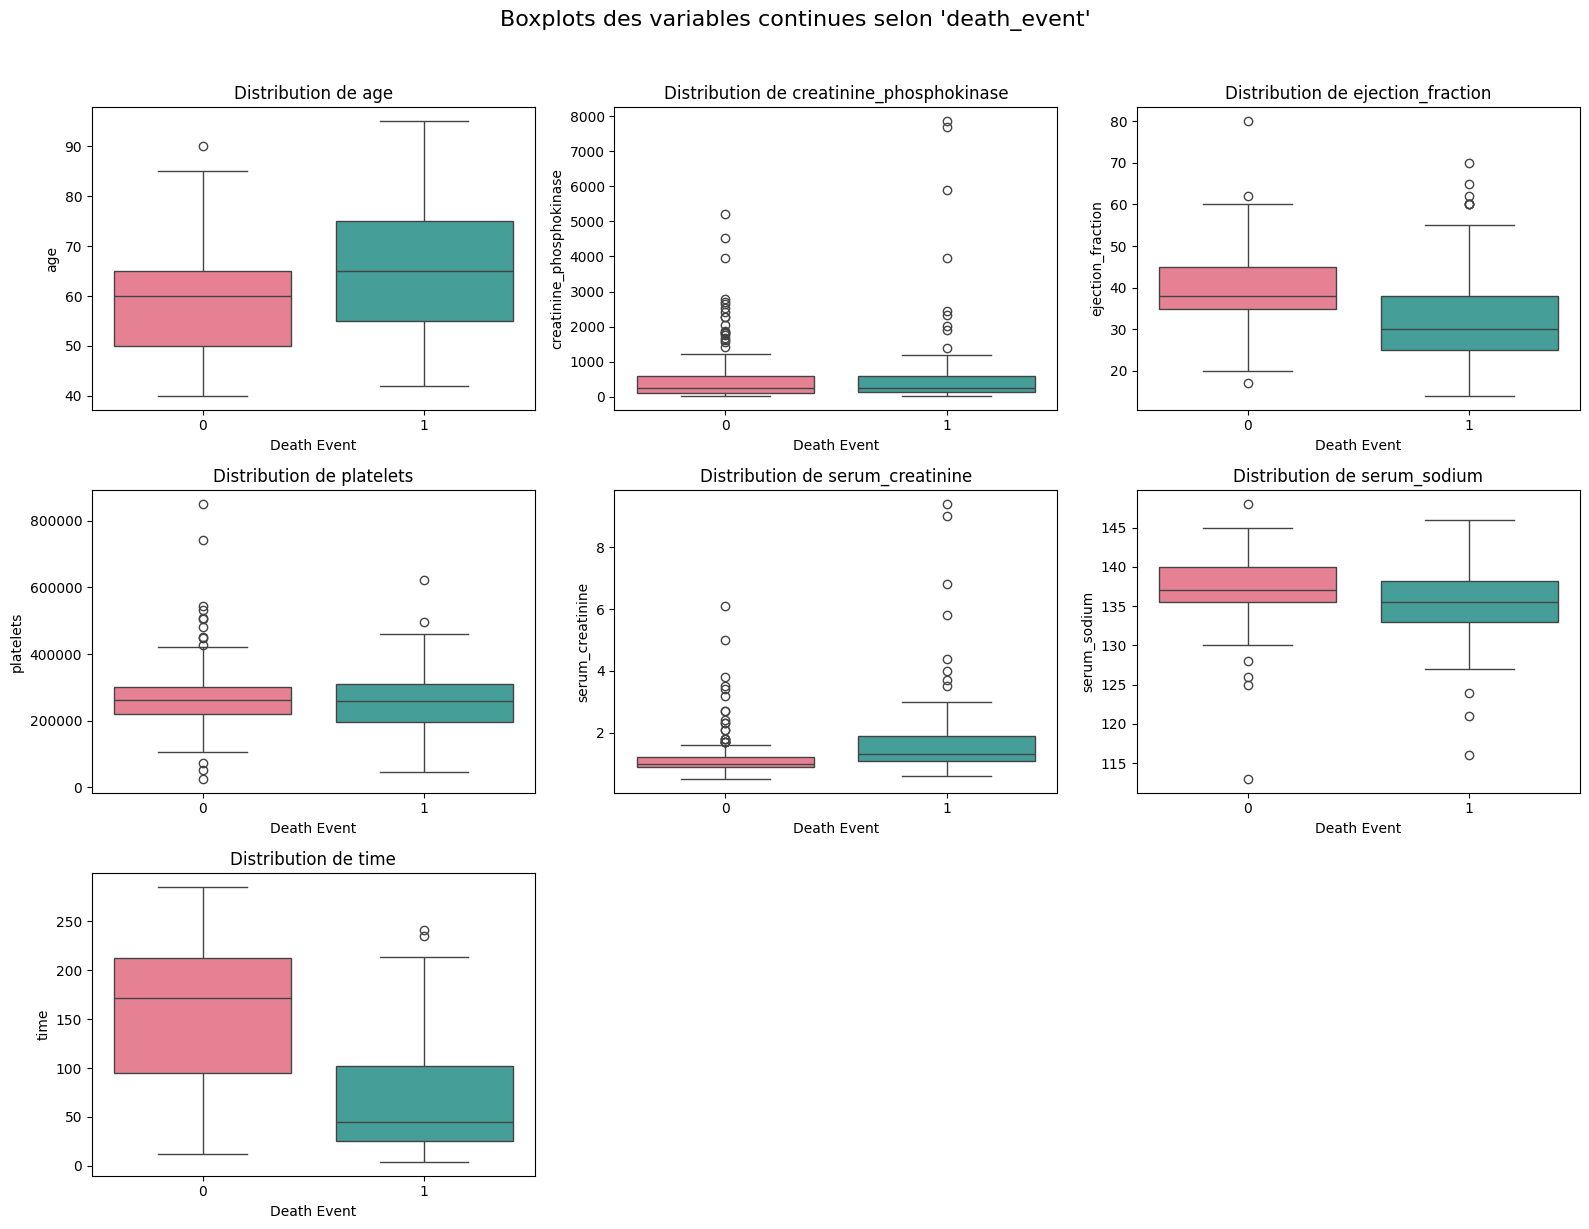

In [18]:

# Liste des variables continues pertinentes pour des boxplots
# (On exclut les variables binaires comme anaemia, diabetes, sex, smoking, etc.)
colonnes_continues = [
    'age', 
    'creatinine_phosphokinase', 
    'ejection_fraction', 
    'platelets', 
    'serum_creatinine', 
    'serum_sodium', 
    'time'
]

# Création d'une grille pour les graphiques (3 lignes, 3 colonnes)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten() # Aplatir l'array pour itérer facilement dessus

# Génération d'un boxplot pour chaque variable
for i, col in enumerate(colonnes_continues):
    # On utilise x="death_event" pour séparer et colorier
    sns.boxplot(
        data=df, 
        x="death_event", 
        y=col, 
        ax=axes[i], 
        palette="husl" # Maintien de la palette que vous utilisiez déjà
    )
    axes[i].set_title(f'Distribution de {col}', fontsize=12)
    axes[i].set_xlabel("Death Event")
    axes[i].set_ylabel(col)

# Suppression des sous-graphiques vides s'il y en a (ici on a 7 variables pour 9 cases)
for j in range(len(colonnes_continues), len(axes)):
    fig.delaxes(axes[j])

# Ajustement automatique de l'espacement et affichage
plt.suptitle("Boxplots des variables continues selon 'death_event'", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/43/6yhv12xx1q3ftqnxwgfp4gkc0000gn/T/ipykernel_7524/3565427896.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


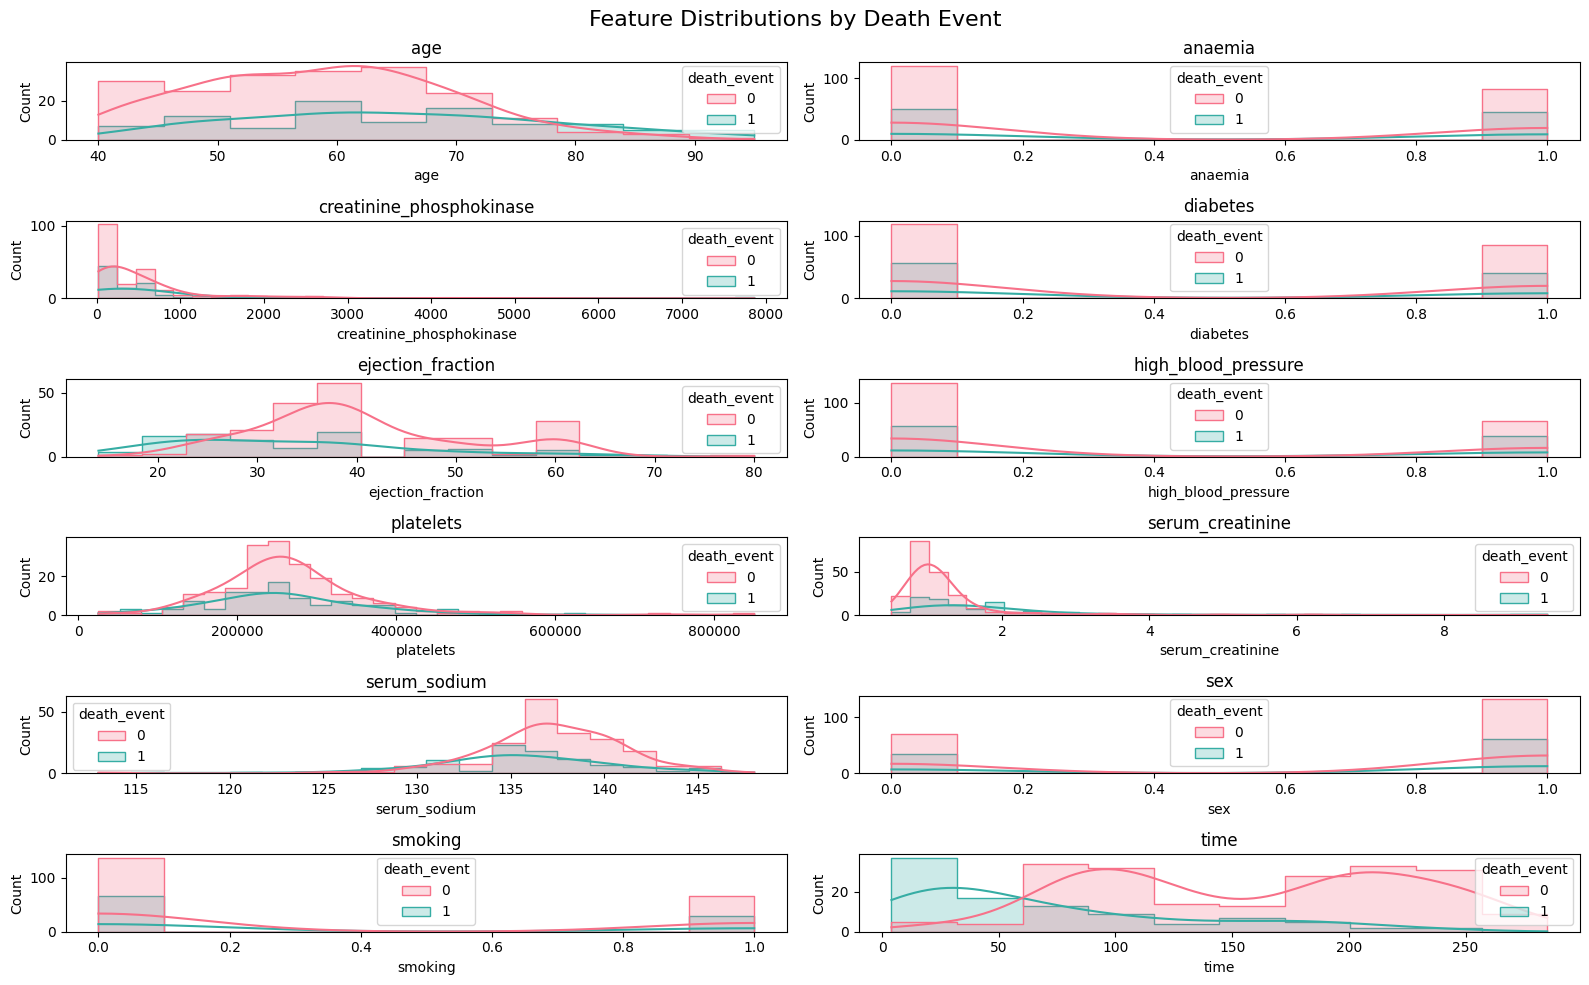

In [19]:
# Histograms for each feature
features = df.columns[:-1]  # Exclude target variable
n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), constrained_layout=True)


#fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.flat, df.columns[:-1]):  # Exclude target variable
    sns.histplot(data=df, x=col, hue="death_event", palette="husl", kde=True, ax=ax, element="step")
    ax.set_title(col)
fig.suptitle("Feature Distributions by Death Event", fontsize=16)
plt.tight_layout()
plt.show()


Globalement, les distributions des deux groupes se chevauchent fortement, ce qui indique qu’aucune variable ne permet à elle seule de séparer parfaitement les patients décédés des survivants.

Cependant, certaines tendances apparaissent :
	•	Age : les patients décédés semblent légèrement plus représentés aux âges élevés. La différence reste modérée et les distributions se recouvrent largement.
	•	Ejection fraction : les patients décédés présentent plus fréquemment des valeurs faibles de fraction d’éjection, suggérant qu’une fonction cardiaque altérée est associée à un risque accru de décès.
	•	Serum creatinine : les patients décédés semblent avoir des valeurs légèrement plus élevées en moyenne, ce qui pourrait refléter une atteinte rénale plus marquée.
    •	Time : les patients décédés semblent avoir une durée de suivie plus courte.
    

Ces différences restent toutefois partielles et non parfaitement discriminantes, ce qui justifie l’utilisation de modèles de classification multivariés afin de combiner l’information de plusieurs variables simultanément.


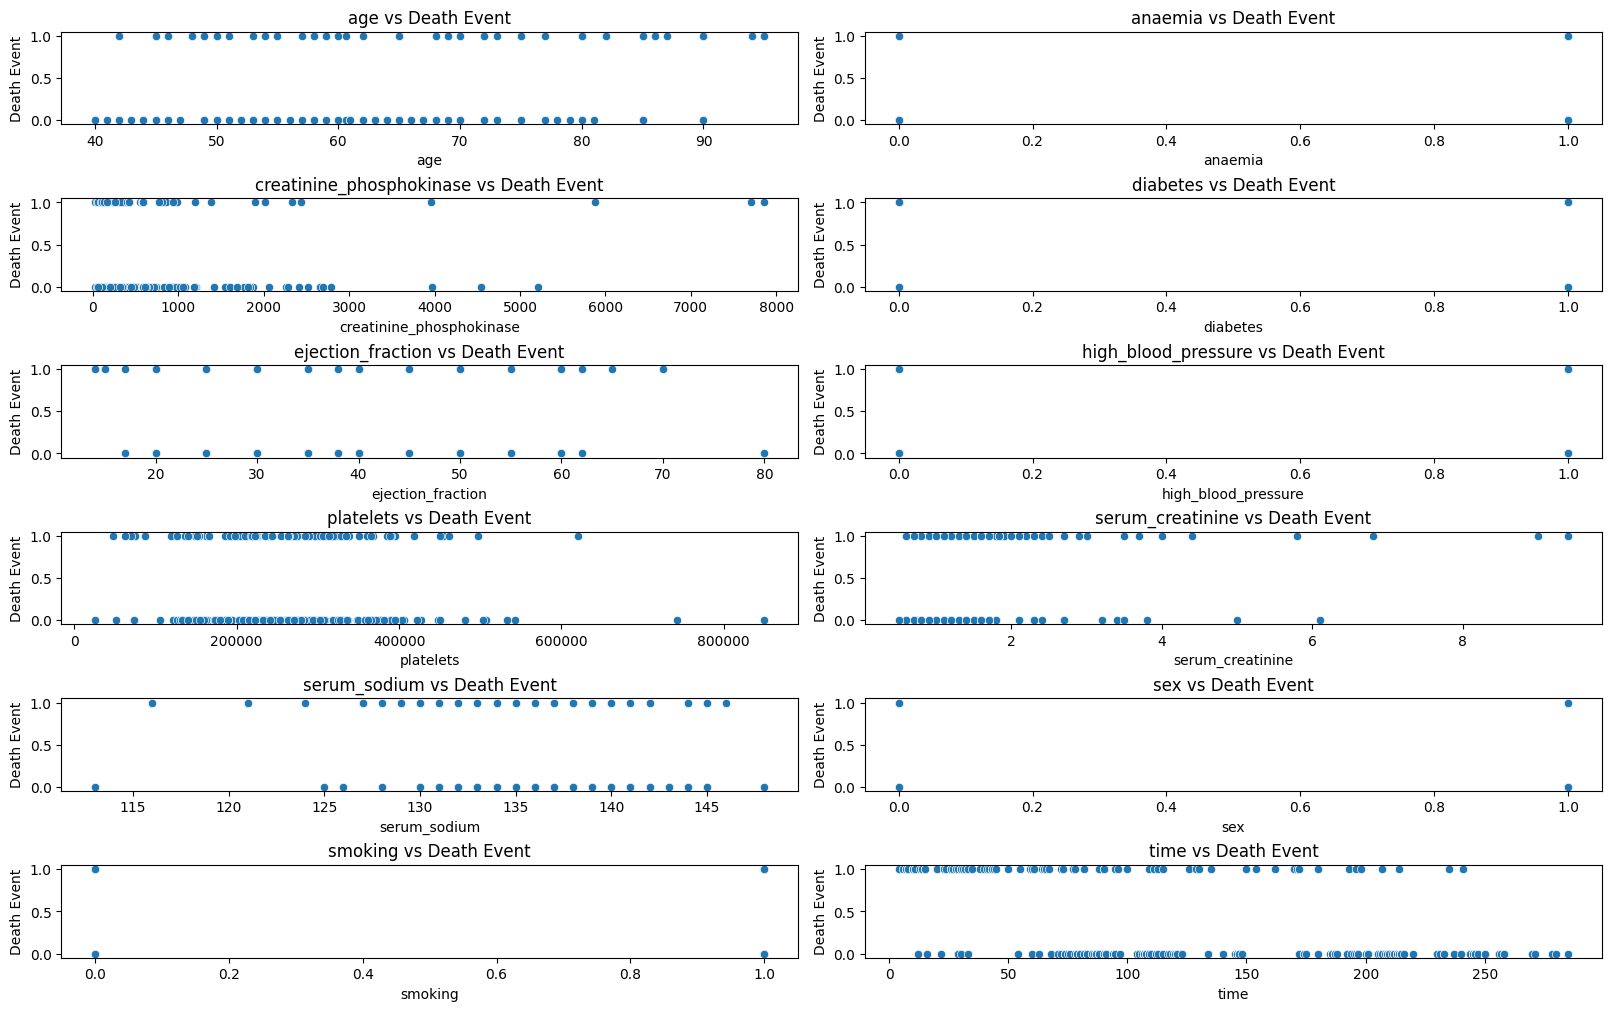

In [20]:
features = df.columns[:-1]  # Exclude target variable
n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.scatterplot(x=df[feature], y=df["death_event"], ax=axes[i])
    axes[i].set_title(f"{feature} vs Death Event")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Death Event")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

Ces graphiques représentent chaque variable en fonction de la variable cible death_event (0 = survie, 1 = décès).

Comme la variable cible est binaire, les points sont répartis sur deux lignes horizontales.
On observe un fort chevauchement entre les deux classes pour la plupart des variables : il n’y a pas de séparation claire.

Cela confirme qu’aucune variable prise isolément ne permet de distinguer parfaitement les patients décédés des survivants.

In [21]:
# Display correlation dataframe
df.corr(numeric_only=True)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,-0.224068,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,0.010514,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,-0.149315,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.015608,-0.004316


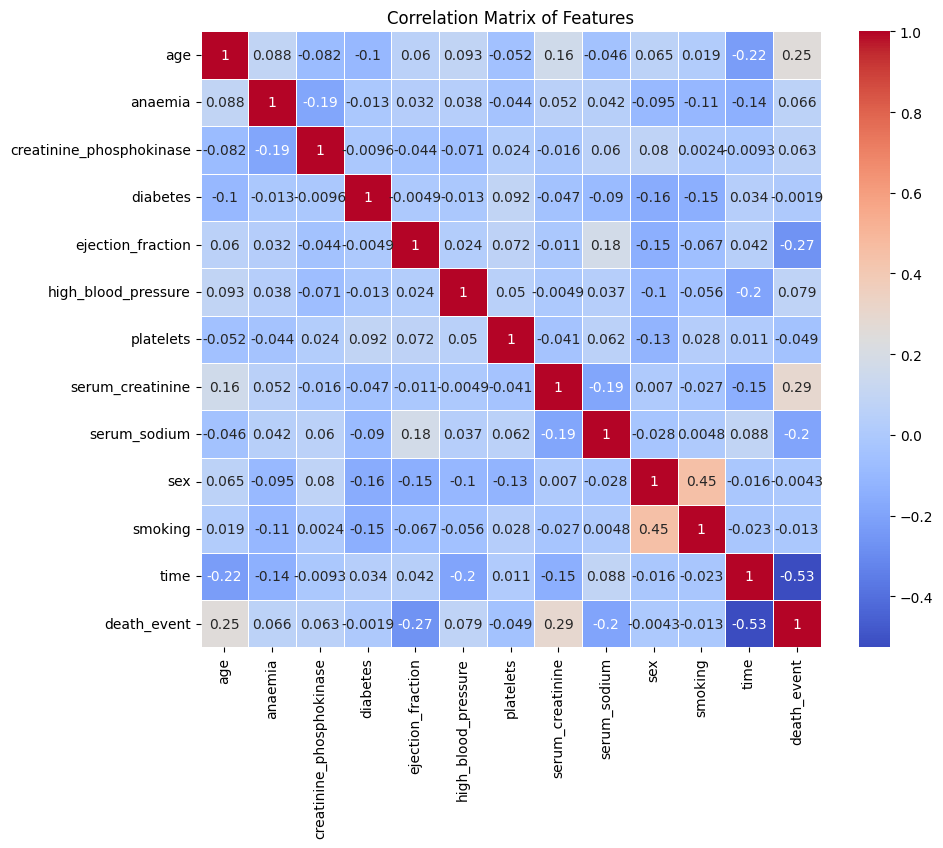

In [22]:
# display correlation matrix of the features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()


La matrice de corrélation confirme l’absence de forte corrélation entre les variables explicatives (la majorité des coefficients sont proches de 0), ce qui limite les risques de multicolinéarité.

Concernant la variable cible death_event, les corrélations les plus notables sont :
	•	time (≈ -0.53) : corrélation négative modérée à forte
	•	serum_creatinine (≈ 0.29) : corrélation positive modérée
	•	ejection_fraction (≈ -0.27) : corrélation négative modérée
	•	age (≈ 0.25) : corrélation positive modérée

Les autres variables présentent des corrélations faibles avec la mortalité.

## 5) Entraînement et évaluation des modèles

Après l’analyse exploratoire des données et les étapes de prétraitement, nous pouvons maintenant entraîner nos modèles de machine learning.

Dans cette tâche de classification supervisée, l’objectif est de prédire la variable cible (death_event) à partir des différentes variables cliniques disponibles (âge, fraction d’éjection, créatinine sérique, etc.). Les variables explicatives (X) représentent les caractéristiques des patients, tandis que la variable cible (Y) indique si le patient est décédé durant la période de suivi.

Afin d’évaluer correctement les performances des modèles, le jeu de données est divisé en un ensemble d’entraînement et un ensemble de test. Les modèles sont ajustés sur les données d’entraînement, puis évalués sur les données de test afin de mesurer leur capacité de généralisation.

Les performances seront comparées à l’aide de métriques classiques de classification : l’accuracy, la précision, le recall et le F1-score.

#A NOTER !

La variable Time pourrait être retiré étant donné qu'elle est très lié à la variable death par construction.

Sa valeur est plutôt une conséquence qu'une cause de la mort des patients



In [23]:
# Make a copy of the original DataFrame to modify it without affecting the original data
df_copy = df.copy()
df_copy = df_copy.drop("time", axis=1)

In [24]:
# Split the dataset into features (X) and target (y)
X = df_copy.drop("death_event", axis=1)
y = df_copy["death_event"]

In [25]:
# Split into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (239, 11)
X_test shape: (60, 11)
y_train shape: (239,)
y_test shape: (60,)



Nous allons entraîner plusieurs modèles de classification couramment utilisés et comparer leurs performances afin d’identifier celui qui prédit le mieux la variable death_event.

In [ ]:
# Define a dictionary of models to train and evaluate {key: model name, value: model instance}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", gamma="scale", random_state=42)
}

results = {}


for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

  # Calculate evaluation metrics for the model
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)
    # Store results in the dictionary
    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

    ## Create a DataFrame from the results dictionary for better visualization


results_df = pd.DataFrame(results).T


results_df.head()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Pyth

,accuracy,precision,recall,f1_score,confusion_matrix
Logistic Regression,0.583333,0.0,0.0,0.0,"[[35, 0], [25, 0]]"
KNN,0.55,0.333333,0.08,0.129032,"[[31, 4], [23, 2]]"
Decision Tree,0.716667,0.722222,0.52,0.604651,"[[30, 5], [12, 13]]"
Random Forest,0.716667,0.75,0.48,0.585366,"[[31, 4], [13, 12]]"
SVM,0.583333,0.0,0.0,0.0,"[[35, 0], [25, 0]]"


## 6) Comparaison des modèles

Nous créons un graphique en barres des performances (accuracy) afin de comparer les différents modèles et d’identifier le plus performant.

In [27]:
# Display the confusion matrix for each model
for name, metrics in results.items():
    print(f"Confusion Matrix for {name}:\n{metrics['confusion_matrix']}\n")

Confusion Matrix for Logistic Regression:
[[35  0]
 [25  0]]

Confusion Matrix for KNN:
[[31  4]
 [23  2]]

Confusion Matrix for Decision Tree:
[[30  5]
 [12 13]]

Confusion Matrix for Random Forest:
[[31  4]
 [13 12]]

Confusion Matrix for SVM:
[[35  0]
 [25  0]]



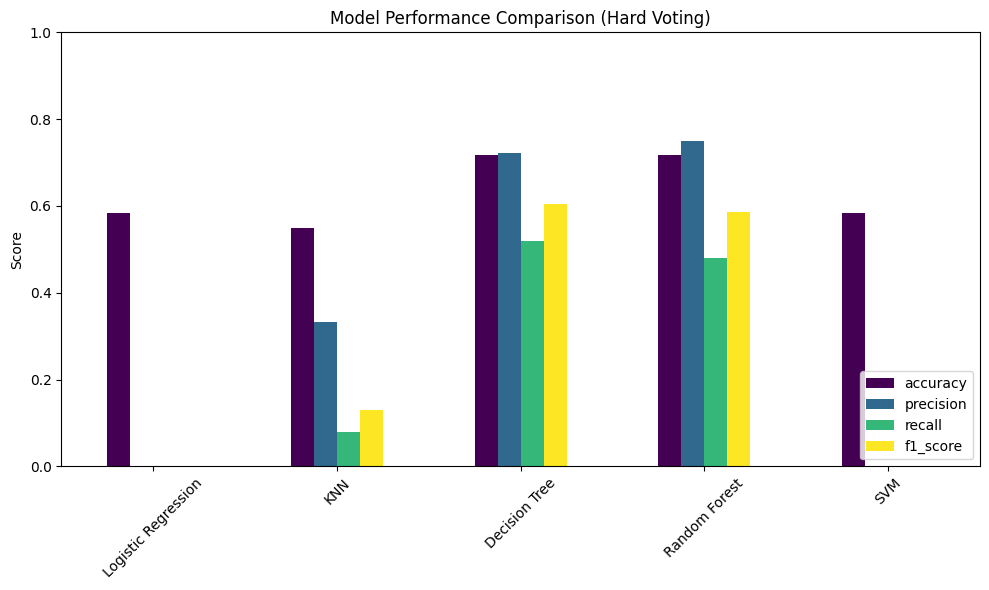

In [28]:
# Plotting the results
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]
results_df[metrics_to_plot].plot(kind="bar", colormap="viridis", figsize=(10, 6))
plt.title("Model Performance Comparison (Hard Voting)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Les modèles ont été entraînés sur les données brutes, sans normalisation.
On observe que :
	•	La Random Forest est le modèle le plus performant (meilleure accuracy et meilleur F1-score).
	•	Le Decision Tree donne des résultats corrects mais inférieurs.
	•	La Logistic Regression et le SVM prédisent uniquement la classe majoritaire (recall = 0), ce qui indique un problème de convergence ou de déséquilibre.
	•	Le KNN est peu performant, probablement car il est sensible à l’échelle des variables.

Ces résultats suggèrent que la normalisation pourrait améliorer les performances des modèles sensibles aux distances ou à l’optimisation (KNN, SVM, Logistic Regression).

# Partie 2 :
Dans cette partie, nous allons appliquer une normalisation des variables explicatives à l’aide de StandardScaler.

La normalisation permet de centrer les variables (moyenne = 0) et de les réduire (écart-type = 1).
Cela est particulièrement important pour les modèles sensibles à l’échelle des variables, comme :
	•	la régression logistique
	•	le KNN
	•	le SVM

Nous allons donc :
	1.	Séparer les données en train/test
	2.	Appliquer la normalisation sur les variables explicatives
	3.	Réentraîner les mêmes modèles
	4.	Comparer les performances avec celles obtenues sans normalisation

In [29]:
# Make a copy of the original DataFrame to modify it without affecting the original data
df_scaler = df.copy()

In [30]:
# Split the dataset into features (X) and target (y)
X_scale = df_scaler.drop("death_event", axis=1)
y_scale = df_scaler["death_event"]  

In [31]:
# Split into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train_scale, X_test_scale, y_train_scale, y_test_scale = train_test_split(X_scale, y_scale, test_size=0.2, random_state=42)   
# Create scaled version 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_scale)
X_test_scaled = scaler.transform(X_test_scale)  
# Display the shapes of the training and testing sets
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train_scale shape: {y_train_scale.shape}")
print(f"y_test_scale shape: {y_test_scale.shape}")  


X_train_scaled shape: (239, 12)
X_test_scaled shape: (60, 12)
y_train_scale shape: (239,)
y_test_scale shape: (60,)


In [32]:
results_scaled = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_scale)
    predictions_scaled = model.predict(X_test_scaled)

  # Calculate evaluation metrics for the model
    accuracy_scaled = accuracy_score(y_test_scale, predictions_scaled)
    precision_scaled = precision_score(y_test_scale, predictions_scaled)
    recall_scaled = recall_score(y_test_scale, predictions_scaled)
    f1_scaled = f1_score(y_test_scale, predictions_scaled)
    cm_scaled = confusion_matrix(y_test_scale, predictions_scaled)
    # Store results in the dictionary
    results_scaled[name] = {
        "accuracy": accuracy_scaled,
        "precision": precision_scaled,
        "recall": recall_scaled,
        "f1_score": f1_scaled,
        "confusion_matrix": cm_scaled
    }
## Create a DataFrame from the results dictionary for better visualization
results_df_scaled = pd.DataFrame(results_scaled).T  # Transpose for better readability
results_df_scaled.head()    

,accuracy,precision,recall,f1_score,confusion_matrix
Logistic Regression,0.8,0.933333,0.56,0.7,"[[34, 1], [11, 14]]"
KNN,0.683333,1.0,0.24,0.387097,"[[35, 0], [19, 6]]"
Decision Tree,0.633333,0.578947,0.44,0.5,"[[27, 8], [14, 11]]"
Random Forest,0.75,0.857143,0.48,0.615385,"[[33, 2], [13, 12]]"
SVM,0.75,0.857143,0.48,0.615385,"[[33, 2], [13, 12]]"


In [33]:
# Display the confusion matrix for each model
for name, metrics in results_scaled.items():
    print(f"Confusion Matrix for {name}:\n{metrics['confusion_matrix']}\n")

Confusion Matrix for Logistic Regression:
[[34  1]
 [11 14]]

Confusion Matrix for KNN:
[[35  0]
 [19  6]]

Confusion Matrix for Decision Tree:
[[27  8]
 [14 11]]

Confusion Matrix for Random Forest:
[[33  2]
 [13 12]]

Confusion Matrix for SVM:
[[33  2]
 [13 12]]



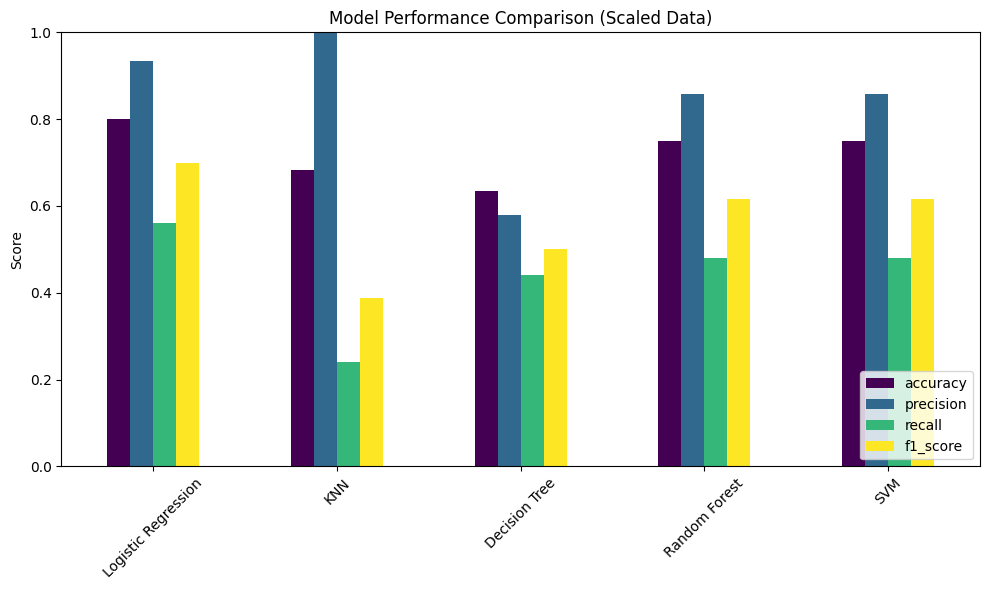

In [34]:
#plotting the results
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]
results_df_scaled[metrics_to_plot].plot(kind="bar", colormap="viridis", figsize=(10, 6))
plt.title("Model Performance Comparison (Scaled Data)")    
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Après normalisation :
	•	Régression logistique : reste le modèle le plus équilibré (bonne accuracy et bon F1-score).
	•	Random Forest et SVM : performances proches, stables.
	•	KNN : amélioration de la précision mais recall faible, il détecte mal la classe positive.
	•	Decision Tree : performances correctes mais inférieures aux meilleurs modèles.

Comparaison globale
	•	La normalisation améliore surtout les modèles basés sur la distance (KNN, SVM).
	•	Les modèles d’arbres (Decision Tree, Random Forest) sont peu impactés par la normalisation.
	•	Globalement, la régression logistique reste le modèle le plus performant et le plus équilibré sur ce dataset.

# Partie 3
## 1) Sélection des variables

À partir de l’analyse exploratoire (boxplot), nous observons que certaines variables présentent peu ou pas de différence notable entre les patients survivants et décédés. 

Ces variables apportent donc une information limitée pour la discrimination de la variable cible *death_event*. Afin d’améliorer la pertinence du modèle et d’éviter d’introduire du bruit inutile, nous décidons de retirer les variables peu discriminantes.

Nous construisons ainsi un nouveau jeu de données contenant uniquement les variables les plus informatives.


In [35]:
# Drop unnecessary columns
df_cleaned1 = df_scaler.copy()
df_cleaned1 = df_cleaned1.drop(columns=["creatinine_phosphokinase", "platelets", "serum_sodium"])

## 2) Nouvelle phase de modélisation

Nous allons maintenant entraîner et tester les modèles de classification sur ce jeu de données réduit.

L’objectif est d’évaluer si la suppression des variables peu pertinentes permet d’améliorer les performances prédictives du modèle.

In [36]:
# Split the dataset into features (X) and target (y)
X_1 = df_cleaned1.drop("death_event", axis=1)
y_1 = df_cleaned1["death_event"]

In [37]:
# Split into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print(f"X_train1 shape: {X_train1.shape}")
print(f"X_test1 shape: {X_test1.shape}")
print(f"y_train1 shape: {y_train1.shape}")
print(f"y_test1 shape: {y_test1.shape}")


X_train1 shape: (239, 9)
X_test1 shape: (60, 9)
y_train1 shape: (239,)
y_test1 shape: (60,)


In [ ]:
# Define a dictionary of models to train and evaluate {key: model name, value: model instance}
models1 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", gamma="scale", random_state=42)
}

results1 = {}

for name, model1 in models1.items():
    model1.fit(X_train1, y_train1)
    predictions1 = model1.predict(X_test1)

    # Calculate evaluation metrics for the model
    accuracy = accuracy_score(y_test1, predictions1)
    precision = precision_score(y_test1, predictions1)
    recall = recall_score(y_test1, predictions1)
    f1 = f1_score(y_test1, predictions1)
    cm = confusion_matrix(y_test1, predictions1)
    # Store results in the dictionary
    results1[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }
 ## Create a DataFrame from the results dictionary for better visualization


results_df1 = pd.DataFrame(results1).T


results_df1.head()
    



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1_score,confusion_matrix
Logistic Regression,0.783333,0.875,0.56,0.682927,"[[33, 2], [11, 14]]"
KNN,0.75,0.857143,0.48,0.615385,"[[33, 2], [13, 12]]"
Decision Tree,0.716667,0.722222,0.52,0.604651,"[[30, 5], [12, 13]]"
Random Forest,0.733333,0.8,0.48,0.6,"[[32, 3], [13, 12]]"
SVM,0.716667,0.833333,0.4,0.540541,"[[33, 2], [15, 10]]"


In [39]:
# Display the confusion matrix for each model
for name, metrics in results1.items():
    print(f"Confusion Matrix for {name}:\n{metrics['confusion_matrix']}\n")

Confusion Matrix for Logistic Regression:
[[33  2]
 [11 14]]

Confusion Matrix for KNN:
[[33  2]
 [13 12]]

Confusion Matrix for Decision Tree:
[[30  5]
 [12 13]]

Confusion Matrix for Random Forest:
[[32  3]
 [13 12]]

Confusion Matrix for SVM:
[[33  2]
 [15 10]]



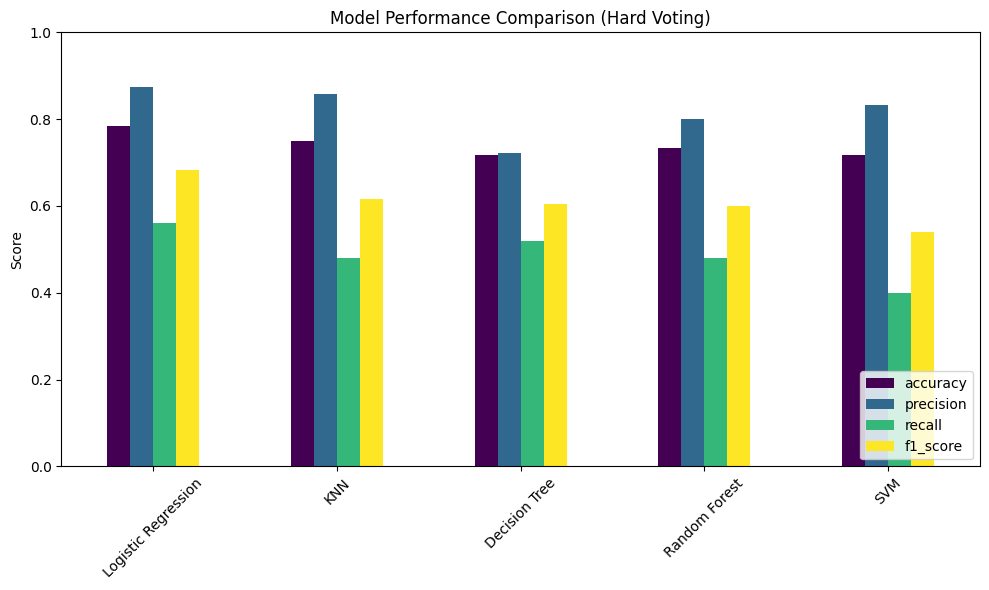

In [40]:
# Plotting the results
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]
results_df1[metrics_to_plot].plot(kind="bar", colormap="viridis", figsize=(10, 6))
plt.title("Model Performance Comparison (Hard Voting)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Après avoir retiré les variables peu discriminantes, les modèles ont été réentraînés sur le nouveau jeu de données réduit.

On observe que :

- La régression logistique reste le modèle le plus équilibré, avec de bonnes performances globales (accuracy et F1-score).
- Le KNN conserve une précision relativement élevée mais présente toujours un recall plus faible, ce qui signifie qu’il détecte moins bien les patients décédés.
- Random Forest et SVM montrent des performances stables, mais sans amélioration notable par rapport à la version précédente.
- L’arbre de décision reste globalement en dessous des autres modèles.

La suppression des variables n’a donc pas entraîné d’amélioration significative des performances.

## Comparaison avec le modèle initial 

La comparaison des métriques montre que la suppression des variables peu discriminantes n’a pas permis d’améliorer les performances globales des modèles.

La régression logistique reste le modèle le plus équilibré dans les deux cas. Toutefois, après suppression, on observe une légère diminution de l’accuracy (0.80 → 0.78) et du F1-score (0.70 → 0.68), tandis que le recall reste identique.

Les modèles Random Forest et SVM présentent également une légère baisse de performance après réduction des variables. Le KNN montre une amélioration du recall, mais ses performances globales restent inférieures à celles de la régression logistique.

Ainsi, bien que la réduction des variables simplifie le modèle et améliore son interprétabilité, elle n’apporte pas de gain prédictif significatif sur ce jeu de données.

# Partie 4
## 1) Analyse en Composantes Principales (ACP)

L’Analyse en Composantes Principales (ACP) est une méthode de réduction de dimensionnalité.
Elle permet de :
	•	Résumer l’information contenue dans un grand nombre de variables quantitatives.
	•	Identifier les combinaisons linéaires de variables (composantes principales) qui expliquent le plus de variance.
	•	Réduire la redondance entre variables corrélées.
	•	Faciliter l’interprétation et éventuellement améliorer les performances des modèles.

Dans notre jeu de données (prédiction du death_event), plusieurs variables biologiques et cliniques peuvent être corrélées.
L’ACP permet donc d’identifier les structures principales sous-jacentes aux données.

⸻


Explained variance ratio: [0.1416262  0.12915241 0.11090612 0.09292451 0.08648043 0.08115205
 0.07391486 0.06926817 0.06603945 0.05341348 0.05253078 0.04259152]

PCA loadings (rows=features, cols=components):
                             PC1     PC2     PC3     PC4     PC5     PC6  \
age                      -0.0718 -0.4710  0.1323  0.1839  0.2208  0.2716   
anaemia                  -0.2922 -0.2198  0.1920 -0.2885 -0.4354  0.1116   
creatinine_phosphokinase  0.2267  0.1079 -0.0299  0.6505  0.0067 -0.4594   
diabetes                 -0.2635  0.2167 -0.3890 -0.2546  0.2283 -0.1040   
ejection_fraction        -0.2099  0.1838  0.3105  0.3219 -0.0106  0.5488   
high_blood_pressure      -0.2142 -0.2137  0.3917 -0.1925  0.3165 -0.3123   
platelets                -0.1694  0.2405  0.0821  0.0663  0.6932  0.1956   
serum_creatinine         -0.0960 -0.3581 -0.3484  0.4021 -0.0898  0.2705   
serum_sodium             -0.0165  0.2811  0.6067  0.1461 -0.2057 -0.1212   
sex                       0.570

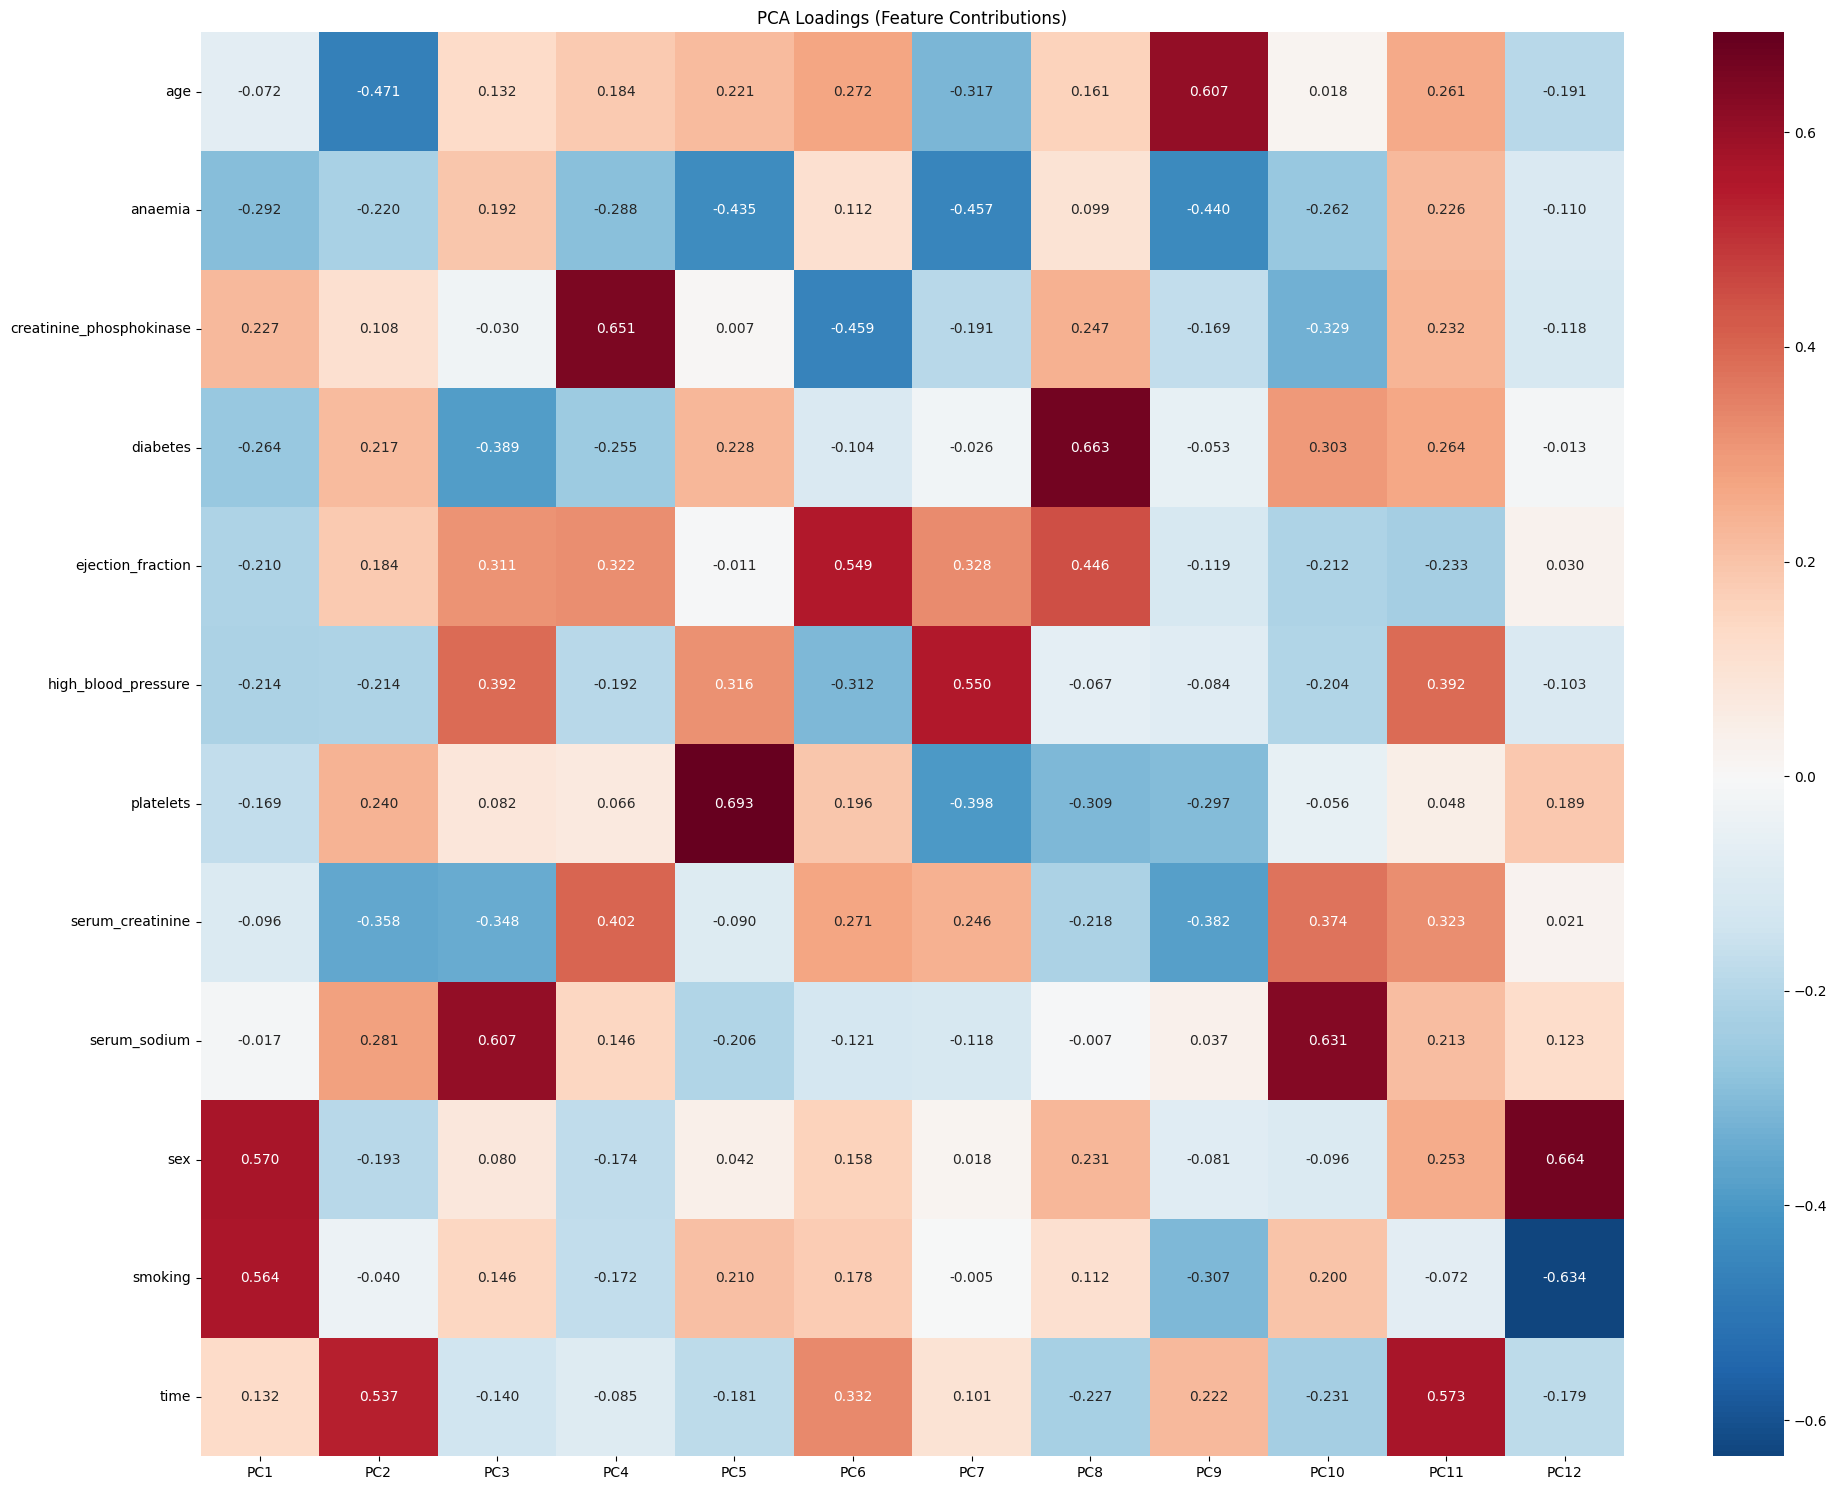

In [49]:
# Plot PCA feature importance
from sklearn.decomposition import PCA   
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# Display PCA loadings (feature contributions)
loadings = pd.DataFrame(pca.components_.T, index=X_train_scale.columns, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA loadings (rows=features, cols=components):")
print(loadings.round(4))


# Heatmap of loadings
plt.figure(figsize=(20, 15))
sns.heatmap(loadings, annot=True, fmt=".3f", cmap='RdBu_r', center=0)
plt.title('PCA Loadings (Feature Contributions)')
plt.tight_layout()
plt.show()

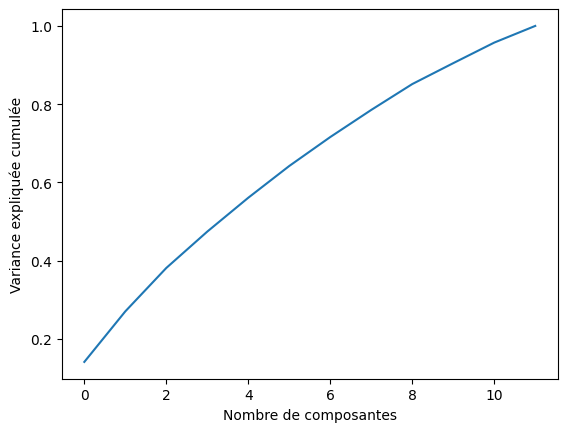

In [42]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.show()

pca_2 = PCA(n_components=0.80)
X_pca_2 = pca_2.fit_transform(X_train_scaled)

Nous avons choisi de conserver les huit premières composantes principales.

Ce choix n’est pas arbitraire : nous avons fixé un seuil de 80 % de variance expliquée cumulée.
Autrement dit, nous avons retenu le nombre minimal de composantes permettant d’expliquer au moins 80 % de la variance totale du jeu de données.

D’après la courbe de variance expliquée cumulée, ce seuil est atteint avec les 8 premières composantes.

Cela permet :
	•	de conserver l’essentiel de l’information,
	•	de réduire la dimension initiale,
	•	et de simplifier l’analyse tout en limitant la perte d’information.

Nous avons ensuite analysé les contributions des variables (loadings) sur ces huit premières composantes. Afin de ne conserver que les variables réellement informatives, nous avons appliqué un seuil de contribution de 0,5 en valeur absolue. Les variables dont les contributions étaient faibles (inférieures à ce seuil) sur l’ensemble des huit premières composantes ont été considérées comme peu informatives dans la structure principale des données.

Ainsi, les variables anaemia, age et serum_creatinine ont été retirées car elles n’apportaient pas d’information significative dans les composantes principales retenues. L’objectif est de réduire la dimension du jeu de données tout en conservant uniquement les variables les plus pertinentes pour la prédiction de la variable cible death_event.

In [43]:
# Drop unnecessary columns
df_cleaned = df_scaler.drop(columns=["anaemia", "age", "serum_creatinine"])

# Split the mod into features (X) and target (y)
X = df_cleaned.drop(columns=["death_event"])
y = df_cleaned["death_event"]

In [44]:
# Split into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X, y, test_size=0.2, random_state=42)   

# display the shapes of the training and testing sets
print(f"X_train_sel shape: {X_train_sel.shape}")
print(f"X_test_sel shape: {X_test_sel.shape}")
print(f"y_train_sel shape: {y_train_sel.shape}")
print(f"y_test_sel shape: {y_test_sel.shape}")

# Train and evaluate models on the selected features
results_selected = {}   

for name, model in models.items():
    model.fit(X_train_sel, y_train_sel)
    predictions_sel = model.predict(X_test_sel)

  # Calculate evaluation metrics for the model
    accuracy_sel = accuracy_score(y_test_sel, predictions_sel)
    precision_sel = precision_score(y_test_sel, predictions_sel)
    recall_sel = recall_score(y_test_sel, predictions_sel)
    f1_sel = f1_score(y_test_sel, predictions_sel)
    cm_sel = confusion_matrix(y_test_sel, predictions_sel)
    # Store results in the dictionary
    results_selected[name] = {
        "accuracy": accuracy_sel,
        "precision": precision_sel,
        "recall": recall_sel,
        "f1_score": f1_sel,
        "confusion_matrix": cm_sel
    }
## Create a DataFrame from the results dictionary for better visualization
results_df_selected = pd.DataFrame(results_selected).T  # Transpose for better readability
results_df_selected.head()

X_train_sel shape: (239, 9)
X_test_sel shape: (60, 9)
y_train_sel shape: (239,)
y_test_sel shape: (60,)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Pyth

,accuracy,precision,recall,f1_score,confusion_matrix
Logistic Regression,0.583333,0.0,0.0,0.0,"[[35, 0], [25, 0]]"
KNN,0.533333,0.2,0.04,0.066667,"[[31, 4], [24, 1]]"
Decision Tree,0.733333,0.764706,0.52,0.619048,"[[31, 4], [12, 13]]"
Random Forest,0.75,0.777778,0.56,0.651163,"[[31, 4], [11, 14]]"
SVM,0.583333,0.0,0.0,0.0,"[[35, 0], [25, 0]]"


In [45]:
# Display the confusion matrix for each model
for name, metrics in results_selected.items():
    print(f"Confusion Matrix for {name}:\n{metrics['confusion_matrix']}\n")

Confusion Matrix for Logistic Regression:
[[35  0]
 [25  0]]

Confusion Matrix for KNN:
[[31  4]
 [24  1]]

Confusion Matrix for Decision Tree:
[[31  4]
 [12 13]]

Confusion Matrix for Random Forest:
[[31  4]
 [11 14]]

Confusion Matrix for SVM:
[[35  0]
 [25  0]]



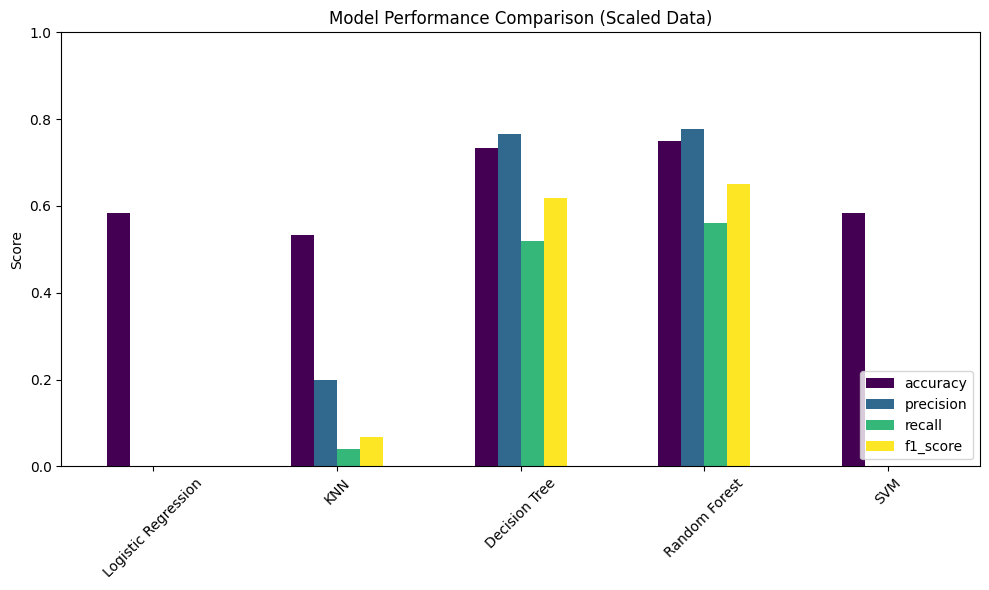

In [46]:
#plotting the results
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]
results_df_selected[metrics_to_plot].plot(kind="bar", colormap="viridis", figsize=(10, 6))
plt.title("Model Performance Comparison (Scaled Data)")
plt.ylabel("Score")        
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



### Interprétation des performances après ACP

L’Analyse en Composantes Principales (ACP) a permis de réduire la dimension du jeu de données en conservant les variables contribuant significativement aux huit premières composantes, expliquant plus de 80 % de la variance totale.

Cette réduction vise à simplifier le modèle et à limiter le bruit potentiel. Toutefois, les résultats montrent que cette transformation impacte différemment les algorithmes, avec une diminution globale des performances pour plusieurs modèles.

En effet, l’ACP a conduit à retirer trois variables, dont l’âge et la serum_creatinine, qui, lors de l’analyse univariée, semblaient pourtant présenter un potentiel explicatif important vis-à-vis de la variable cible (*death_event*). Cela suggère que la contribution à la variance globale n’est pas nécessairement équivalente à la contribution à la discrimination des classes.

Ainsi, bien que la réduction de dimension améliore la simplicité du modèle, elle ne conduit pas à une amélioration prédictive dans ce cas précis. Le modèle le plus performant reste la régression logistique entraînée sur l’ensemble des variables normalisées, offrant le meilleur compromis entre accuracy, recall et F1-score.





### Conclusion générale

L’objectif de ce projet était de comparer plusieurs modèles de classification pour prédire le décès chez des patients atteints d’insuffisance cardiaque.

La normalisation des données améliore globalement les performances des modèles sensibles à l’échelle, notamment la régression logistique et le SVM.

La suppression de variables peu discriminantes n’a pas permis d’obtenir un gain significatif de performance. Les résultats restent similaires à ceux obtenus avec l’ensemble des variables.

L’application de l’ACP et la réduction de dimension ont entraîné une forte dégradation des modèles linéaires, qui ne détectent plus correctement la classe positive. En revanche, les modèles basés sur des arbres, notamment Random Forest, conservent des performances satisfaisantes.

Globalement, la meilleure configuration observée est obtenue avec les données normalisées et l’ensemble des variables initiales. La régression logistique apparaît comme le modèle le plus équilibré, tandis que Random Forest offre une alternative robuste.

Ces résultats montrent que la réduction de dimension par ACP ne garantit pas une amélioration prédictive et peut, dans certains cas, supprimer une information discriminante importante.